# Chapter 7: Data processing excercise


In this lesson we will be using a number of things we have learned in previous lessons. Try to go back to those lessons/notebooks to solve each part of the assignement.

P.S. you can also search the internet/cheat sheets to find the appropriate code for what you want to do. 

Before we start, let's load our favourite libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

## 7.1 Data & pre-processing

The data we will be using for this assignment is the IMDb dataset. IMDb (Internet Movie Database) contains information on almost all movies ever made. All these movies recieve ratings from the public and from critics. 

There are 2 datasets, 'IMDb movies.csv' and 'IMDd ratings.csv'. The names are self-explanatory

### 7.1.1 Data Loading

Load both datasets correctly. Show the top 5 rows of both datasets.

In [61]:
films = pd.read_csv("IMDb movies.csv", sep = ",")
films.head()

C:\Users\rikto\AppData\Local\Temp\ipykernel_4316\1138288998.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  films = pd.read_csv("IMDb movies.csv", sep = ",")


,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894,1894-10-09,Romance,45,USA,NaN,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,1906-12-26,"Biography, Crime, Drama",70,Australia,NaN,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,$ 2250,NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911,1911-08-19,Drama,53,"Germany, Denmark",NaN,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912,1912-11-13,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,$ 45000,NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911,1911-03-06,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


In [62]:
ratings = pd.read_csv("IMDb ratings.csv", sep = ",")
ratings.head()

,imdb_title_id,weighted_average_vote,total_votes,mean_vote,median_vote,votes_10,votes_9,votes_8,votes_7,votes_6,...,females_30age_avg_vote,females_30age_votes,females_45age_avg_vote,females_45age_votes,top1000_voters_rating,top1000_voters_votes,us_voters_rating,us_voters_votes,non_us_voters_rating,non_us_voters_votes
0,tt0000009,5.9,154,5.9,6.0,12,4,10,43,28,...,5.7,13.0,4.5,4.0,5.7,34.0,6.4,51.0,6.0,70.0
1,tt0000574,6.1,589,6.3,6.0,57,18,58,137,139,...,6.2,23.0,6.6,14.0,6.4,66.0,6.0,96.0,6.2,331.0
2,tt0001892,5.8,188,6.0,6.0,6,6,17,44,52,...,5.8,4.0,6.8,7.0,5.4,32.0,6.2,31.0,5.9,123.0
3,tt0002101,5.2,446,5.3,5.0,15,8,16,62,98,...,5.5,14.0,6.1,21.0,4.9,57.0,5.5,207.0,4.7,105.0
4,tt0002130,7.0,2237,6.9,7.0,210,225,436,641,344,...,7.3,82.0,7.4,77.0,6.9,139.0,7.0,488.0,7.0,1166.0


### 7.1.2 Data selection

There are a lot of variables but we do not need all of them. Keep only the following variables:

- movie data: 'imdb_title_id', 'title', 'year', 'genre', 'duration', 'country', 'language', 'avg_vote', 'votes'
- rating data: 'imdb_title_id', 'total_votes', 'weighted_average_vote', 'mean_vote', 'us_voters_rating', 'non_us_voters_rating'

How many rows and columns do we have remaining for each dataset?

In [63]:
films = films[["imdb_title_id", "title", "year", "genre", "duration", "country", "language", "avg_vote", "votes"]]
films.shape

(85855, 9)

In [64]:
ratings = ratings[["imdb_title_id", "total_votes", 'weighted_average_vote', 'mean_vote', 'us_voters_rating', 'non_us_voters_rating']]
ratings.shape

(85855, 6)

### 7.1.3 Data cleaning

There is a movie with a wrong year. This will cause problems when fixing the dtypes of the data.

- What is the movie ID and title of that movie? 
- Fix the year!

*If you cannot figure this out, execute the next line of code and proceed for now. Do come back later to figure it out! **Note:** this line of code is not a solution for the problem, it simply avoids it.*

`films_merged = films_merged[films_merged['imdb_title_id'] !='tt8206668']`

In [65]:
films['year'].astype(int)

ValueError: invalid literal for int() with base 10: 'TV Movie 2019'

In [66]:
films[films['year'] == 'TV Movie 2019']

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes
83917,tt8206668,Bad Education,TV Movie 2019,"Biography, Comedy, Crime",108,USA,English,7.1,23973


In [67]:
films.loc[ films['year'] == 'TV Movie 2019', "year"] = "2019"

In [68]:
films['year']

0        1894
1        1906
2        1911
3        1912
4        1911
         ... 
85850    2020
85851    2020
85852    2019
85853    2019
85854    2019
Name: year, Length: 85855, dtype: object

### 7.1.4 Data merging 

Merge both datasets into 1 DataFrame. Combine the dataframes in such a way that a movie needs to be in both datasets before it ends up in the final merged dataframe.

In [69]:
films_merged = pd.merge(films, ratings, how='inner', left_on='imdb_title_id', right_on='imdb_title_id')

In [70]:
films_merged.head()

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes,total_votes,weighted_average_vote,mean_vote,us_voters_rating,non_us_voters_rating
0,tt0000009,Miss Jerry,1894,Romance,45,USA,NaN,5.9,154,154,5.9,5.9,6.4,6.0
1,tt0000574,The Story of the Kelly Gang,1906,"Biography, Crime, Drama",70,Australia,NaN,6.1,589,589,6.1,6.3,6.0,6.2
2,tt0001892,Den sorte drøm,1911,Drama,53,"Germany, Denmark",NaN,5.8,188,188,5.8,6.0,6.2,5.9
3,tt0002101,Cleopatra,1912,"Drama, History",100,USA,English,5.2,446,446,5.2,5.3,5.5,4.7
4,tt0002130,L'Inferno,1911,"Adventure, Drama, Fantasy",68,Italy,Italian,7.0,2237,2237,7.0,6.9,7.0,7.0


### 7.1.5 new variable

One of the most popular genre combinations is romantic comedies like Notting Hill, Love Actually and Pulp Fiction. 
Make a new variable which is true if there is 'romance' and 'comedy' in the genre. How many romantic comedies are there in the data?

In [71]:
films_merged['Romcom'] = False
films_merged.loc[np.logical_and(films_merged['genre'].str.contains('romance', case = False) , films_merged['genre'].str.contains('comedy', case = False) ), 'Romcom'] = True

In [72]:
films_merged['Romcom'].sum()

6192

In [73]:
films_merged[films_merged.Romcom == True]

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes,total_votes,weighted_average_vote,mean_vote,us_voters_rating,non_us_voters_rating,Romcom
75,tt0006826,Hoodoo Ann,1916,"Comedy, Drama, Romance",65,USA,English,5.6,837,837,5.6,6.7,5.8,5.3,True
78,tt0007047,The Matrimaniac,1916,"Comedy, Romance",46,USA,English,6.0,573,573,6.0,6.7,6.5,5.7,True
113,tt0008775,Wild and Woolly,1917,"Comedy, Western, Romance",72,USA,English,6.4,557,557,6.4,6.8,6.6,6.3,True
114,tt0008827,Amarilly of Clothes-Line Alley,1918,"Comedy, Romance",67,USA,English,5.8,740,740,5.8,6.6,6.2,5.5,True
126,tt0009241,Johanna Enlists,1918,"Comedy, Romance",72,USA,English,5.1,594,594,5.1,6.5,5.5,5.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85775,tt9816396,Kaguya-sama wa kokurasetai ~ Tensai tachi no r...,2019,"Comedy, Drama, Romance",113,Japan,Japanese,5.7,123,123,5.7,6.1,3.5,5.3,True
85782,tt9817760,Jai Mummy Di,2020,"Comedy, Drama, Romance",103,India,Hindi,3.6,661,661,3.6,3.9,3.8,3.7,True
85811,tt9860728,Falling Inn Love - Ristrutturazione con amore,2019,"Comedy, Romance",98,USA,English,5.6,14108,14108,5.6,5.7,5.8,5.5,True
85828,tt9886872,Munthiri Monchan,2019,"Comedy, Romance",130,India,Malayalam,8.1,990,990,8.1,8.8,3.4,4.9,True


### 7.1.6 Encoding & type checks

By checking the encoding we can check for unexpected things. Python loads large datasets in chunks (parts), and an unexpected data type could indicate something wrong. 

Check the encodings and list which ones need fixing. Fix them!

In [74]:
films_merged.dtypes

imdb_title_id             object
title                     object
year                      object
genre                     object
duration                   int64
country                   object
language                  object
avg_vote                 float64
votes                      int64
total_votes                int64
weighted_average_vote    float64
mean_vote                float64
us_voters_rating         float64
non_us_voters_rating     float64
Romcom                      bool
dtype: object

To fix:
year -> int



In [75]:
films_merged['year'] = films_merged['year'].astype('int')

In [76]:
films_merged.dtypes

imdb_title_id             object
title                     object
year                       int32
genre                     object
duration                   int64
country                   object
language                  object
avg_vote                 float64
votes                      int64
total_votes                int64
weighted_average_vote    float64
mean_vote                float64
us_voters_rating         float64
non_us_voters_rating     float64
Romcom                      bool
dtype: object

### 7.1.7 movie countries

I think we all know Hollywood is the biggest movie scene in the world. But who is in second place? 

*Hint: Use the Country variable and not the language variable.*

In [77]:
films_merged['country'].value_counts()

country
USA                                       28511
India                                      6065
UK                                         4111
Japan                                      3077
France                                     3055
                                          ...  
Denmark, Iceland, Norway                      1
Mexico, France, Belgium, Germany              1
UK, Germany, Kenya, France, USA, China        1
Germany, Ireland, Taiwan                      1
India, Netherlands, Singapore                 1
Name: count, Length: 4907, dtype: int64

### 7.1.8 Holywood movies


Let's focus on the 'Hollywood' movie scene, so select all movies from the USA.

Answer the following questions

1. What's the year of the oldest movie in the Hollywood data
2. What's the year of the youngest movie in this data

If there is only one oldest or youngest movie, give the name. If there are multiple, give the amount of movies.

In [78]:
films_merged = films_merged[films_merged['country'] == 'USA']

In [79]:
films_merged['language'].value_counts()

language
English                                             24831
English, Spanish                                      710
English, French                                       452
English, Italian                                      206
English, German                                       205
                                                    ...  
Mandarin, English, Cantonese, Vietnamese, Polish        1
English, Korean, Spanish, Japanese, Latin               1
English, German, Russian, French                        1
English, Spanish, Cantonese, Italian                    1
English, Finnish, French, Vietnamese                    1
Name: count, Length: 649, dtype: int64

In [80]:
films_merged['year'].min()

1894

In [81]:
films_merged[films_merged['year']  == films_merged['year'].min()]

,imdb_title_id,title,year,genre,duration,country,language,avg_vote,votes,total_votes,weighted_average_vote,mean_vote,us_voters_rating,non_us_voters_rating,Romcom
0,tt0000009,Miss Jerry,1894,Romance,45,USA,NaN,5.9,154,154,5.9,5.9,6.4,6.0,False


In [82]:
films_merged[films_merged['year']  == films_merged['year'].min()].title

0    Miss Jerry
Name: title, dtype: object

In [83]:
films_merged['year'].max()

2020

In [84]:
len(films_merged[films_merged['year']  == films_merged['year'].max()])

276

### 7.1.9 Standardize (Z-score) the movie scores 'avg_vote'

Use the formula and not some python pakage for this. i.e. you can use functions such as mean(), median(), min(), max, std(), IQR(), etc.

Save this data in a new variable named 'standardized_vote'

In [85]:
films_merged['standardized_vote'] = ( films_merged['avg_vote'] - films_merged['avg_vote'].mean() ) / films_merged['avg_vote'].std()

## 7.2 Calculations 

In this section we are going to calculate some aggregate results per year and per decade. Specifically, we are interested in the average and standard deviation of the scores per year/decade. In this way we can hopefully answer the question which year/decade was rated the best for cinema. We are going to do this by writing a function that does these calculations for us

### 7.2.1 Write a function that calculates metrics per year

- Mean of 'avg_vote'
- Standard deviation of 'avg_vote'
- Mean of 'standardized_vote'
- Standard deviation of 'standardized_vote'
- Mean of 'duration'
- Standard deviation of 'duration'
- Total amount of movies

Use this function to answer the following questions:

1. In what year where most movies produced?
2. Which year had the highest average vote?
3. In what year were the standardized votes the least spread out?
4. Which year has the shortest movies?

In [95]:
def Aggregate_movie_data_per_year(films_merged):
    
    years = pd.unique(films_merged['year'])
    
    vote_avg = []
    vote_std = []
    z_vote_avg = []
    z_vote_std = []
    movie_length_avg = []
    movie_length_std = []
    N_movies = []
    
    for year in years:
        films_subset = films_merged[films_merged['year'] == year]
            
        vote_avg.append(films_subset['avg_vote'].mean())
        vote_std.append(films_subset['avg_vote'].std())
        
        z_vote_avg.append(films_subset['standardized_vote'].mean())
        z_vote_std.append(films_subset['standardized_vote'].std())
        
        movie_length_avg.append(films_subset['duration'].mean())
        movie_length_std.append(films_subset['duration'].std())
        
        N_movies.append(len(films_subset['year']))
        
        
    results = pd.DataFrame({'year': years,
                            'vote_avg': vote_avg,
                            'vote_std': vote_std,
                            'z_vote_avg': z_vote_avg,
                            'z_vote_std': z_vote_std,
                            'movie_length_avg': movie_length_avg,
                            'movie_length_std': movie_length_std,
                            'N_movies': N_movies})
    
    return(results)

In [96]:
agg_films_year = Aggregate_movie_data_per_year(films_merged)
agg_films_year.head()

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
0,1894,5.90000,NaN,0.267679,NaN,45.000000,NaN,1
1,1912,5.45000,0.353553,-0.082568,0.275180,80.000000,28.284271,2
2,1914,5.91875,0.405329,0.282273,0.315478,73.312500,35.254728,16
3,1913,6.00000,NaN,0.345511,NaN,88.000000,NaN,1
4,1915,6.26000,0.352136,0.547876,0.274077,74.066667,34.900812,15


In [97]:
agg_films_year[agg_films_year.N_movies == agg_films_year.N_movies.max()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
102,2017,5.050276,1.265183,-0.393683,0.984724,92.98232,13.029991,905


In [98]:
agg_films_year[agg_films_year.vote_avg == agg_films_year.vote_avg.max()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
18,1928,6.716667,0.900878,0.903311,0.701177,84.15,15.973309,60


In [99]:
agg_films_year[agg_films_year.z_vote_std == agg_films_year.z_vote_std.min()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
4,1915,6.26,0.352136,0.547876,0.274077,74.066667,34.900812,15


In [101]:
agg_films_year[agg_films_year.movie_length_avg == agg_films_year.movie_length_avg.min()]

,year,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
0,1894,5.9,NaN,0.267679,NaN,45.0,NaN,1


### 7.2.2 Adapt your function to calculates metrics per decade

Only consider decades up to the 2010's.

Keep the same variables as before. Use the new function to answer the same questions as 7.2.1. Do your answers change?

In [102]:
decades = list(range(1910,2020,10))
decades

[1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010]

In [111]:
def Aggregate_movie_data_per_decade(films_merged):
    
    decades = list(range(1910,2020,10))
    
    vote_avg = []
    vote_std = []
    z_vote_avg = []
    z_vote_std = []
    movie_length_avg = []
    movie_length_std = []
    N_movies = []

    
    for decade in decades:
        films_subset = films_merged[(films_merged['year'] >= decade) & (films_merged['year'] <= decade+9) ]
    

        vote_avg.append(films_subset['avg_vote'].mean())
        vote_std.append(films_subset['avg_vote'].std())
        
        z_vote_avg.append(films_subset['standardized_vote'].mean())
        z_vote_std.append(films_subset['standardized_vote'].std())

        movie_length_avg.append(films_subset['duration'].mean())
        movie_length_std.append(films_subset['duration'].std())
        
        N_movies.append(len(films_subset['year']))
        
    
    results = pd.DataFrame({'decade': decades,
                            'vote_avg': vote_avg,
                            'vote_std': vote_std,
                            'z_vote_avg': z_vote_avg,
                            'z_vote_std': z_vote_std,
                            'movie_length_avg': movie_length_avg,
                            'movie_length_std': movie_length_std,
                            'N_movies': N_movies})
    
    return(results)

In [112]:
agg_films_decade = Aggregate_movie_data_per_decade(films_merged)
agg_films_decade

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
0,1910,6.101681,0.644400,0.424652,0.501553,72.857143,24.939005,119
1,1920,6.462661,0.771049,0.705612,0.600127,84.884120,21.900937,466
2,1930,6.289343,0.696819,0.570715,0.542352,80.938907,27.156536,2177
3,1940,6.411520,0.702221,0.665808,0.546557,87.401226,26.859932,2283
4,1950,6.222268,0.863492,0.518508,0.672078,89.474288,18.543238,2178
5,1960,5.908205,1.183516,0.274065,0.921161,98.698168,22.386855,1365
6,1970,5.681829,1.232194,0.097871,0.959048,97.290244,16.511904,1640
7,1980,5.517175,1.226621,-0.030284,0.954711,96.551570,13.090183,2230
8,1990,5.416274,1.241475,-0.108817,0.966272,97.843599,14.914748,3312
9,2000,5.184086,1.346338,-0.289536,1.047889,95.132834,13.995892,4675


In [113]:
agg_films_decade[agg_films_decade.N_movies == agg_films_decade.N_movies.max()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
10,2010,5.078277,1.34013,-0.371889,1.043057,93.666324,14.408041,7789


In [114]:
agg_films_decade[agg_films_decade.vote_avg == agg_films_decade.vote_avg.max()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
1,1920,6.462661,0.771049,0.705612,0.600127,84.88412,21.900937,466


In [115]:
agg_films_decade[agg_films_decade.z_vote_std == agg_films_decade.z_vote_std.min()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
0,1910,6.101681,0.6444,0.424652,0.501553,72.857143,24.939005,119


In [116]:
agg_films_decade[agg_films_decade.movie_length_avg == agg_films_decade.movie_length_avg.min()]

,decade,vote_avg,vote_std,z_vote_avg,z_vote_std,movie_length_avg,movie_length_std,N_movies
0,1910,6.101681,0.6444,0.424652,0.501553,72.857143,24.939005,119


## 7.3 Visualising results

### 7.3.1 Visualise the average scores (+/- SD) over time

Visualise the average scores per year. Also show the spread of each year's scores by showing the standard deviation.

There is a high chance your data will look weird, if so: fix it.

*Hint: remember we are working with a linear passage of time...*

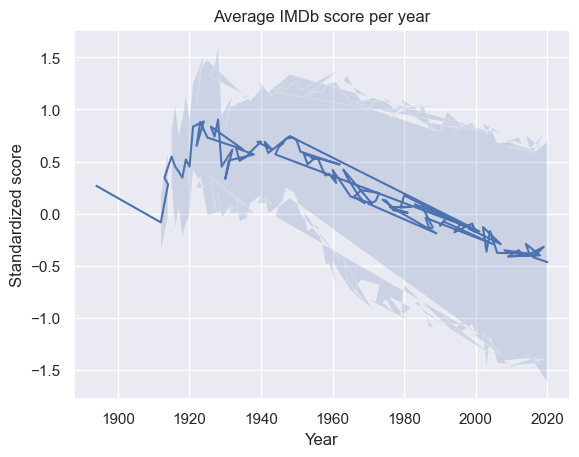

In [122]:
plt.figure()
plt.title("Average IMDb score per year");
plt.xlabel('Year')
plt.ylabel('Standardized score')
plt.plot(agg_films_year['year'], agg_films_year['z_vote_avg'])

z_vote_min = agg_films_year['z_vote_avg'] - agg_films_year['z_vote_std']
z_vote_max = agg_films_year['z_vote_avg'] + agg_films_year['z_vote_std']

plt.fill_between(agg_films_year['year'], z_vote_min, z_vote_max, alpha = 0.2)

In [123]:
agg_films_year.sort_values(by=['year'], inplace = True)

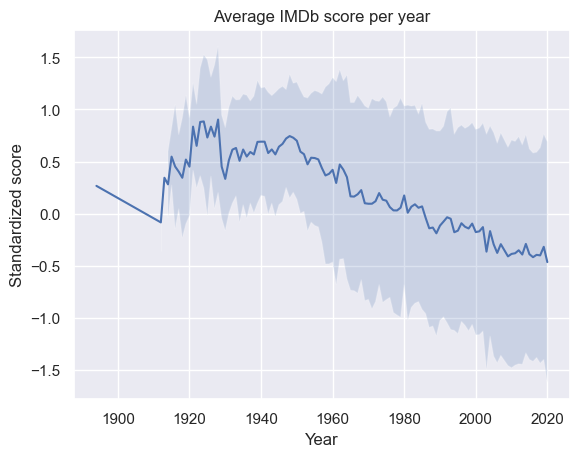

In [127]:
plt.figure()
plt.title("Average IMDb score per year");
plt.xlabel('Year')
plt.ylabel('Standardized score')
plt.plot(agg_films_year['year'], agg_films_year['z_vote_avg'])

z_vote_min = agg_films_year['z_vote_avg'] - agg_films_year['z_vote_std']
z_vote_max = agg_films_year['z_vote_avg'] + agg_films_year['z_vote_std']

plt.fill_between(agg_films_year['year'], z_vote_min, z_vote_max, alpha = 0.2)

### 7.3.2 Visualise the average scores (+/- SD) over time, and add the decade based data as an errorbar visual.

*Hint: this is a new element to visualize your data, so do some research!*

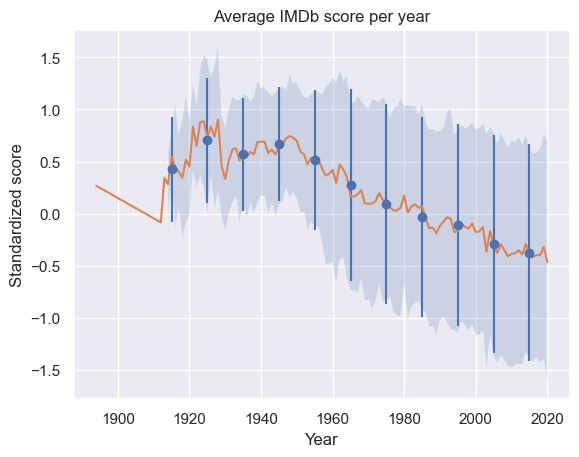

In [141]:
plt.figure()
plt.errorbar(agg_films_decade['decade'] + 5, agg_films_decade['z_vote_avg'], yerr = agg_films_decade['z_vote_std'], fmt = 'o')
plt.title("Average IMDb score per year");
plt.xlabel('Year')
plt.ylabel('Standardized score')
plt.plot(agg_films_year['year'], agg_films_year['z_vote_avg'])

z_vote_min = agg_films_year['z_vote_avg'] - agg_films_year['z_vote_std']
z_vote_max = agg_films_year['z_vote_avg'] + agg_films_year['z_vote_std']

plt.fill_between(agg_films_year['year'], z_vote_min, z_vote_max, alpha = 0.2)

### 7.3.3 Change the previous plot but plot Us vs non-US votes.

You no longer need to show the standard deviation or decade errorplots.

Adjust your function to include this information.

In [142]:
def Aggregate_movie_data_per_year(films_merged):
    
    years = pd.unique(films_merged['year'])
    
    vote_avg = []
    vote_std = []
    z_vote_avg = []
    z_vote_std = []
    movie_length_avg = []
    movie_length_std = []
    N_movies = []
    us_avg = []
    non_us_avg = []
    
    for year in years:
        films_subset = films_merged[films_merged['year'] == year]
            
        vote_avg.append(films_subset['avg_vote'].mean())
        vote_std.append(films_subset['avg_vote'].std())
        
        z_vote_avg.append(films_subset['standardized_vote'].mean())
        z_vote_std.append(films_subset['standardized_vote'].std())
        
        movie_length_avg.append(films_subset['duration'].mean())
        movie_length_std.append(films_subset['duration'].std())
        
        N_movies.append(len(films_subset['year']))

        us_avg.append(films_subset['us_voters_rating'].mean())
        non_us_avg.append(films_subset['non_us_voters_rating'].mean())
        
        
    results = pd.DataFrame({'year': years,
                            'vote_avg': vote_avg,
                            'vote_std': vote_std,
                            'z_vote_avg': z_vote_avg,
                            'z_vote_std': z_vote_std,
                            'movie_length_avg': movie_length_avg,
                            'movie_length_std': movie_length_std,
                            'N_movies': N_movies,
                            'us_avg': us_avg,
                            'non_us_avg': non_us_avg})
    
    return(results)

In [143]:
agg_films_year = Aggregate_movie_data_per_year(films_merged)
agg_films_year.sort_values(by=['year'], inplace = True)

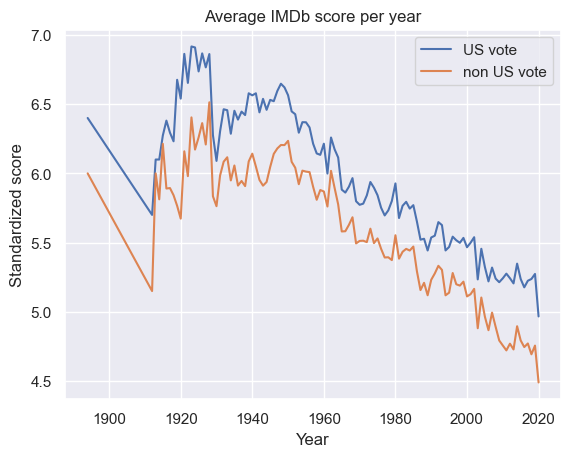

In [151]:
plt.figure()
plt.title("Average IMDb score per year");
plt.xlabel('Year')
plt.ylabel('Standardized score')
plt.plot(agg_films_year['year'], agg_films_year['us_avg'], label = 'US vote')
plt.plot(agg_films_year['year'], agg_films_year['non_us_avg'], label = 'non US vote')
plt.legend()

### 7.3.4 Calculate the difference in rating between us votes and non-us votes

Create a function to calulate the difference in rating for each movie. Show this yearly difference in a histogram. Show the median and standard deviation.

In [152]:
def Rating_diff_per_year(films_merged):
    
    years = pd.unique(films_merged['year'])

    us_avg = []
    non_us_avg = []
    rating_diff_avg = []
    rating_diff_std = []
    
    for year in years:
        films_subset = films_merged[films_merged['year'] == year]

        us_avg.append(films_subset['us_voters_rating'].mean())
        non_us_avg.append(films_subset['non_us_voters_rating'].mean())

        rating_diff = films_subset['us_voters_rating'] - films_subset['non_us_voters_rating']
        rating_diff_avg.append(rating_diff.mean())
        rating_diff_std.append(rating_diff.std())
        
        
    results = pd.DataFrame({'year': years,
                            'us_avg': us_avg,
                            'non_us_avg': non_us_avg,
                            'rating_diff_avg': rating_diff_avg,
                            'rating_diff_std': rating_diff_std})
    
    return(results)

In [153]:
rating_diff_per_year = Rating_diff_per_year(films_merged)
rating_diff_per_year.sort_values(by=['year'], inplace = True)

Text(0, 0.5, 'Count')

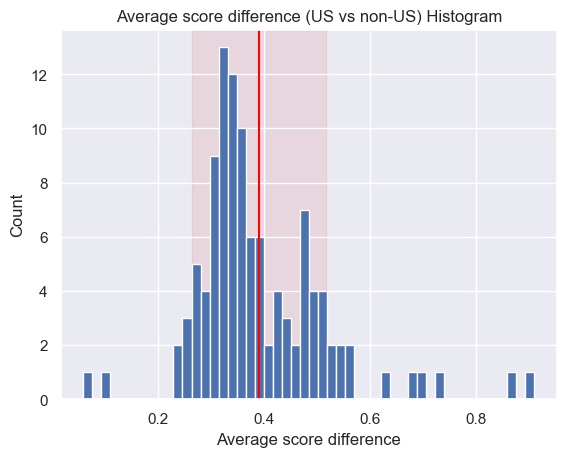

In [163]:
plt.hist(rating_diff_per_year['rating_diff_avg'], bins=50)
plt.axvline(rating_diff_per_year['rating_diff_avg'].mean(), label = "mean", color = "red")
plt.axvspan(
    rating_diff_per_year['rating_diff_avg'].mean() - rating_diff_per_year['rating_diff_avg'].std(),
    rating_diff_per_year['rating_diff_avg'].mean() + rating_diff_per_year['rating_diff_avg'].std(),
    zorder = 0, color = 'tab:red', alpha = 0.1)
plt.title("Average score difference (US vs non-US) Histogram");
plt.xlabel('Average score difference')
plt.ylabel('Count')

### 7.3.5 Show the difference in rating between us votes and non-us votes on a plot

Show the caluculated difference on a plot. Also show the standard deviation per year.

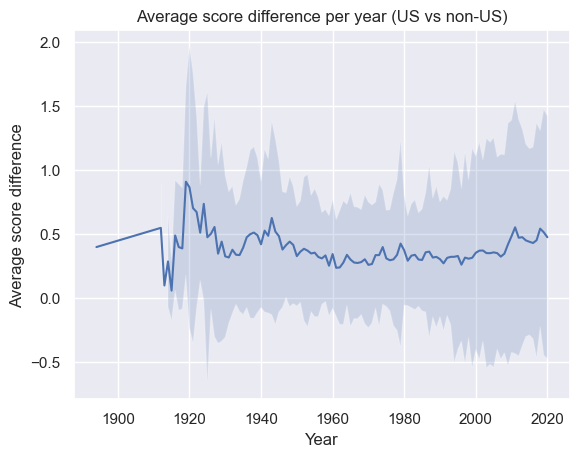

In [164]:
plt.figure()
plt.title("Average score difference per year (US vs non-US)");
plt.xlabel('Year')
plt.ylabel('Average score difference')
plt.plot(rating_diff_per_year['year'], rating_diff_per_year['rating_diff_avg'])

rating_diff_min = rating_diff_per_year['rating_diff_avg'] - rating_diff_per_year['rating_diff_std']
rating_diff_max = rating_diff_per_year['rating_diff_avg'] + rating_diff_per_year['rating_diff_std']

plt.fill_between(rating_diff_per_year['year'], rating_diff_min, rating_diff_max, alpha = 0.2)